# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 33: HYBRID MULTI-LABEL PER-LABEL THRESHOLD TUNING
# ============================================================
# Purpose:
# This notebook improves the hybrid multi-label pilot by replacing
# the single global threshold with per-label thresholds learned
# on the fused validation probabilities.
#
# The goal is to:
# 1. Load aligned structured and audio pilot outputs
# 2. Recreate the best hybrid fusion from Notebook 32
# 3. Learn per-label thresholds on the fused validation set
# 4. Optionally test simple label caps
# 5. Evaluate the improved hybrid on the test set
# 6. Compare global-threshold hybrid vs per-label-threshold hybrid
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [2]:
# ============================================================
# 2. LOAD STRUCTURED AND AUDIO PILOT OUTPUTS
# ============================================================

structured_val_probs = np.load("../data/processed/structured_on_audio_pilot_candidate150_val_probs.npy")
structured_test_probs = np.load("../data/processed/structured_on_audio_pilot_candidate150_test_probs.npy")

audio_val_probs = np.load("../data/processed/audio_multilabel_candidate150_pilot_val_probs.npy")
audio_test_probs = np.load("../data/processed/audio_multilabel_candidate150_pilot_test_probs.npy")

Y_val_structured = np.load("../data/processed/structured_on_audio_pilot_candidate150_y_val.npy")
Y_test_structured = np.load("../data/processed/structured_on_audio_pilot_candidate150_y_test.npy")

Y_val_audio = np.load("../data/processed/audio_multilabel_candidate150_pilot_y_val.npy")
Y_test_audio = np.load("../data/processed/audio_multilabel_candidate150_pilot_y_test.npy")

structured_val_track_ids = np.load("../data/processed/structured_on_audio_pilot_candidate150_val_track_ids.npy")
structured_test_track_ids = np.load("../data/processed/structured_on_audio_pilot_candidate150_test_track_ids.npy")

audio_val_track_ids = np.load("../data/processed/audio_multilabel_candidate150_pilot_val_track_ids.npy")
audio_test_track_ids = np.load("../data/processed/audio_multilabel_candidate150_pilot_test_track_ids.npy")

structured_label_cols = np.load(
    "../data/processed/structured_on_audio_pilot_candidate150_label_columns.npy",
    allow_pickle=True
)

audio_label_cols = np.load(
    "../data/processed/audio_multilabel_candidate150_pilot_label_columns.npy",
    allow_pickle=True
)

print("Structured val probs shape:", structured_val_probs.shape)
print("Structured test probs shape:", structured_test_probs.shape)
print("Audio val probs shape:", audio_val_probs.shape)
print("Audio test probs shape:", audio_test_probs.shape)
print("Y_val_structured shape:", Y_val_structured.shape)
print("Y_test_structured shape:", Y_test_structured.shape)
print("Y_val_audio shape:", Y_val_audio.shape)
print("Y_test_audio shape:", Y_test_audio.shape)

Structured val probs shape: (1000, 150)
Structured test probs shape: (1000, 150)
Audio val probs shape: (1000, 150)
Audio test probs shape: (1000, 150)
Y_val_structured shape: (1000, 150)
Y_test_structured shape: (1000, 150)
Y_val_audio shape: (1000, 150)
Y_test_audio shape: (1000, 150)


In [3]:
# ============================================================
# 3. VERIFY ALIGNMENT
# ============================================================

print("Label columns match:", np.array_equal(structured_label_cols, audio_label_cols))
print("Validation track IDs match:", np.array_equal(structured_val_track_ids, audio_val_track_ids))
print("Test track IDs match:", np.array_equal(structured_test_track_ids, audio_test_track_ids))
print("Validation targets match:", np.array_equal(Y_val_structured, Y_val_audio))
print("Test targets match:", np.array_equal(Y_test_structured, Y_test_audio))

assert np.array_equal(structured_label_cols, audio_label_cols), "Label columns do not match."
assert np.array_equal(structured_val_track_ids, audio_val_track_ids), "Validation track IDs do not match."
assert np.array_equal(structured_test_track_ids, audio_test_track_ids), "Test track IDs do not match."
assert np.array_equal(Y_val_structured, Y_val_audio), "Validation targets do not match."
assert np.array_equal(Y_test_structured, Y_test_audio), "Test targets do not match."

label_cols = structured_label_cols.copy()
Y_val = Y_val_structured.copy()
Y_test = Y_test_structured.copy()

print("Number of labels:", len(label_cols))

Label columns match: True
Validation track IDs match: True
Test track IDs match: True
Validation targets match: True
Test targets match: True
Number of labels: 150


In [4]:
# ============================================================
# 4. LOAD BEST HYBRID CONFIG FROM NOTEBOOK 32
# ============================================================

best_config = {}
with open("../data/processed/hybrid_multilabel_candidate150_pilot_best_config.txt", "r") as f:
    for line in f:
        line = line.strip()
        if "=" in line:
            k, v = line.split("=")
            best_config[k.strip()] = float(v.strip())

best_w_structured = best_config["structured_weight"]
best_w_audio = best_config["audio_weight"]
best_global_threshold = best_config["threshold"]

print("Best hybrid config from Notebook 32:")
print("Structured weight:", best_w_structured)
print("Audio weight:", best_w_audio)
print("Global threshold:", best_global_threshold)

Best hybrid config from Notebook 32:
Structured weight: 0.1
Audio weight: 0.9
Global threshold: 0.2


In [5]:
# ============================================================
# 5. DEFINE HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def fuse_probabilities(structured_probs, audio_probs, w_structured=0.5, w_audio=0.5):
    return (w_structured * structured_probs) + (w_audio * audio_probs)

def decode_global_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def decode_per_label_threshold(prob_matrix, thresholds, ensure_at_least_one=False):
    y_pred = np.zeros_like(prob_matrix, dtype=np.uint8)

    for j in range(prob_matrix.shape[1]):
        y_pred[:, j] = (prob_matrix[:, j] >= thresholds[j]).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def apply_label_cap(prob_matrix, y_pred, max_labels=None, ensure_at_least_one=False):
    y_final = y_pred.copy()

    if max_labels is not None:
        for i in range(y_final.shape[0]):
            pos_idx = np.where(y_final[i] == 1)[0]

            if len(pos_idx) > max_labels:
                pos_scores = prob_matrix[i, pos_idx]
                keep_order = np.argsort(-pos_scores)[:max_labels]
                keep_idx = pos_idx[keep_order]

                y_final[i, :] = 0
                y_final[i, keep_idx] = 1

    if ensure_at_least_one:
        row_sums = y_final.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_final[zero_rows, top_idx] = 1

    return y_final

In [6]:
# ============================================================
# 6. RECREATE THE BEST HYBRID FUSED PROBABILITIES
# ============================================================

fused_val_probs = fuse_probabilities(
    structured_val_probs,
    audio_val_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

fused_test_probs = fuse_probabilities(
    structured_test_probs,
    audio_test_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

print("Fused validation probability shape:", fused_val_probs.shape)
print("Fused test probability shape:", fused_test_probs.shape)

Fused validation probability shape: (1000, 150)
Fused test probability shape: (1000, 150)


In [7]:
# ============================================================
# 7. RECREATE BASELINE HYBRID RESULTS (GLOBAL THRESHOLD)
# ============================================================

Y_val_pred_global = decode_global_threshold(
    fused_val_probs,
    best_global_threshold,
    ensure_at_least_one=False
)

Y_test_pred_global = decode_global_threshold(
    fused_test_probs,
    best_global_threshold,
    ensure_at_least_one=False
)

global_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_global,
    name="Hybrid Global Threshold"
)

global_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_global,
    name="Hybrid Global Threshold"
)

p3_val_global, r3_val_global = precision_recall_at_k(Y_val, fused_val_probs, k=3)
p5_val_global, r5_val_global = precision_recall_at_k(Y_val, fused_val_probs, k=5)

global_val_results["Precision@3"] = p3_val_global
global_val_results["Recall@3"] = r3_val_global
global_val_results["Precision@5"] = p5_val_global
global_val_results["Recall@5"] = r5_val_global

p3_test_global, r3_test_global = precision_recall_at_k(Y_test, fused_test_probs, k=3)
p5_test_global, r5_test_global = precision_recall_at_k(Y_test, fused_test_probs, k=5)

global_test_results["Precision@3"] = p3_test_global
global_test_results["Recall@3"] = r3_test_global
global_test_results["Precision@5"] = p5_test_global
global_test_results["Recall@5"] = r5_test_global

print("Recreated hybrid validation results:")
print(global_val_results)

print("\nRecreated hybrid test results:")
print(global_test_results)

Recreated hybrid validation results:
{'Model': 'Hybrid Global Threshold', 'Micro F1': 0.37100509495136635, 'Macro F1': 0.047075423566482776, 'Samples F1': 0.36622308247308244, 'Micro Precision': 0.33955065705807547, 'Micro Recall': 0.40888208269525267, 'Hamming Loss': 0.036213333333333333, 'Subset Accuracy': 0.002, 'Avg Predicted Labels': 4.718, 'Precision@3': 0.42766666666666664, 'Recall@3': 0.36409444444444444, 'Precision@5': 0.3266, 'Recall@5': 0.453793253968254}

Recreated hybrid test results:
{'Model': 'Hybrid Global Threshold', 'Micro F1': 0.3783526046012636, 'Macro F1': 0.04930099343344162, 'Samples F1': 0.37267043136601957, 'Micro Precision': 0.34077732445780545, 'Micro Recall': 0.4252411575562701, 'Hamming Loss': 0.03476666666666667, 'Subset Accuracy': 0.001, 'Avg Predicted Labels': 4.657, 'Precision@3': 0.417, 'Recall@3': 0.3709108585858586, 'Precision@5': 0.32600000000000007, 'Recall@5': 0.4716756854256854}


In [8]:
# ============================================================
# 8. LEARN PER-LABEL THRESHOLDS ON FUSED VALIDATION PROBABILITIES
# ============================================================

threshold_grid = np.arange(0.05, 0.55, 0.05)
best_thresholds_per_label = np.zeros(fused_val_probs.shape[1], dtype=np.float32)

for j in range(fused_val_probs.shape[1]):
    y_true_j = Y_val[:, j]
    probs_j = fused_val_probs[:, j]

    best_f1_j = -1.0
    best_t_j = threshold_grid[0]

    for t in threshold_grid:
        y_pred_j = (probs_j >= t).astype(np.uint8)
        f1_j = f1_score(y_true_j, y_pred_j, zero_division=0)

        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j = t

    best_thresholds_per_label[j] = best_t_j

print("Per-label thresholds learned for fused probabilities.")
print("Unique thresholds chosen:", np.unique(best_thresholds_per_label))

Per-label thresholds learned for fused probabilities.
Unique thresholds chosen: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.5 ]


In [9]:
# ============================================================
# 9. EVALUATE HYBRID WITH PER-LABEL THRESHOLDS
# ============================================================

Y_val_pred_per_label = decode_per_label_threshold(
    fused_val_probs,
    best_thresholds_per_label,
    ensure_at_least_one=False
)

Y_test_pred_per_label = decode_per_label_threshold(
    fused_test_probs,
    best_thresholds_per_label,
    ensure_at_least_one=False
)

per_label_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_per_label,
    name="Hybrid Per-Label Thresholds"
)

per_label_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_per_label,
    name="Hybrid Per-Label Thresholds"
)

per_label_val_results["Precision@3"] = p3_val_global
per_label_val_results["Recall@3"] = r3_val_global
per_label_val_results["Precision@5"] = p5_val_global
per_label_val_results["Recall@5"] = r5_val_global

per_label_test_results["Precision@3"] = p3_test_global
per_label_test_results["Recall@3"] = r3_test_global
per_label_test_results["Precision@5"] = p5_test_global
per_label_test_results["Recall@5"] = r5_test_global

print("Hybrid per-label validation results:")
print(per_label_val_results)

print("\nHybrid per-label test results:")
print(per_label_test_results)

Hybrid per-label validation results:
{'Model': 'Hybrid Per-Label Thresholds', 'Micro F1': 0.1982742960944596, 'Macro F1': 0.09577416998550178, 'Samples F1': 0.20117740181171928, 'Micro Precision': 0.12059440945751851, 'Micro Recall': 0.5571720265441552, 'Hamming Loss': 0.11769333333333333, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 18.102, 'Precision@3': 0.42766666666666664, 'Recall@3': 0.36409444444444444, 'Precision@5': 0.3266, 'Recall@5': 0.453793253968254}

Hybrid per-label test results:
{'Model': 'Hybrid Per-Label Thresholds', 'Micro F1': 0.18703400618294236, 'Macro F1': 0.09183868772247208, 'Samples F1': 0.19181030001143073, 'Micro Precision': 0.11262593079281646, 'Micro Recall': 0.5511789924973205, 'Hamming Loss': 0.11921333333333334, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 18.264, 'Precision@3': 0.417, 'Recall@3': 0.3709108585858586, 'Precision@5': 0.32600000000000007, 'Recall@5': 0.4716756854256854}


In [10]:
# ============================================================
# 10. OPTIONAL LABEL-CAP SEARCH ON VALIDATION
# ============================================================

cap_results = []

for cap in [None, 8, 6, 5, 4, 3]:
    Y_val_pred_cap = apply_label_cap(
        fused_val_probs,
        Y_val_pred_per_label,
        max_labels=cap,
        ensure_at_least_one=False
    )

    cap_name = "Hybrid Per-Label Thresholds" if cap is None else f"Hybrid Per-Label + Cap-{cap}"

    results = evaluate_multilabel(
        Y_val,
        Y_val_pred_cap,
        name=cap_name
    )

    results["Cap"] = "None" if cap is None else cap
    cap_results.append(results)

cap_results_df = pd.DataFrame(cap_results).sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).reset_index(drop=True)

print("Hybrid validation label-cap search:")
display(cap_results_df)

Hybrid validation label-cap search:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Cap
0,Hybrid Per-Label + Cap-3,0.375542,0.043528,0.378194,0.433000,0.331547,0.028800,0.009,3.000,3
1,Hybrid Per-Label + Cap-4,0.375095,0.057115,0.374316,0.371250,0.379020,0.032987,0.003,4.000,4
2,Hybrid Per-Label + Cap-5,0.366226,0.067796,0.363080,0.326600,0.416794,0.037680,0.000,5.000,5
3,Hybrid Per-Label + Cap-6,0.354507,0.074606,0.350503,0.293000,0.448698,0.042680,0.000,6.000,6
4,Hybrid Per-Label + Cap-8,0.320154,0.086566,0.315139,0.238524,0.486728,0.053993,0.000,7.995,8
5,Hybrid Per-Label Thresholds,0.198274,0.095774,0.201177,0.120594,0.557172,0.117693,0.000,18.102,None


In [11]:
# ============================================================
# 11. SELECT BEST FINAL HYBRID DECODING RULE
# ============================================================

best_cap_row = cap_results_df.iloc[0].to_dict()
best_cap_value = best_cap_row["Cap"]

print("Best final hybrid decoding rule:")
print(best_cap_row)

Best final hybrid decoding rule:
{'Model': 'Hybrid Per-Label + Cap-3', 'Micro F1': 0.375542064180399, 'Macro F1': 0.04352796750832856, 'Samples F1': 0.37819368409368403, 'Micro Precision': 0.433, 'Micro Recall': 0.3315467075038285, 'Hamming Loss': 0.0288, 'Subset Accuracy': 0.009, 'Avg Predicted Labels': 3.0, 'Cap': 3}


In [12]:
# ============================================================
# 12. APPLY BEST FINAL DECODING RULE TO TEST
# ============================================================

if best_cap_value == "None":
    Y_test_pred_final = Y_test_pred_per_label.copy()
    final_test_results = per_label_test_results.copy()
else:
    Y_test_pred_final = apply_label_cap(
        fused_test_probs,
        Y_test_pred_per_label,
        max_labels=int(best_cap_value),
        ensure_at_least_one=False
    )

    final_test_results = evaluate_multilabel(
        Y_test,
        Y_test_pred_final,
        name=f"Hybrid Per-Label + Best Cap"
    )

    final_test_results["Precision@3"] = p3_test_global
    final_test_results["Recall@3"] = r3_test_global
    final_test_results["Precision@5"] = p5_test_global
    final_test_results["Recall@5"] = r5_test_global

print("Final hybrid test results:")
print(final_test_results)

Final hybrid test results:
{'Model': 'Hybrid Per-Label + Best Cap', 'Micro F1': 0.37670825906120026, 'Macro F1': 0.04667447180418245, 'Samples F1': 0.37962039072039067, 'Micro Precision': 0.4226666666666667, 'Micro Recall': 0.3397642015005359, 'Hamming Loss': 0.027973333333333333, 'Subset Accuracy': 0.009, 'Avg Predicted Labels': 3.0, 'Precision@3': 0.417, 'Recall@3': 0.3709108585858586, 'Precision@5': 0.32600000000000007, 'Recall@5': 0.4716756854256854}


In [13]:
# ============================================================
# 13. BUILD GLOBAL VS PER-LABEL VS FINAL TEST COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    global_test_results,
    per_label_test_results,
    final_test_results
]).drop_duplicates(subset=["Model"]).reset_index(drop=True)

print("Hybrid test comparison:")
display(comparison_df)

Hybrid test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Hybrid Global Threshold,0.378353,0.049301,0.37267,0.340777,0.425241,0.034767,0.001,4.657,0.417,0.370911,0.326,0.471676
1,Hybrid Per-Label Thresholds,0.187034,0.091839,0.19181,0.112626,0.551179,0.119213,0.000,18.264,0.417,0.370911,0.326,0.471676
2,Hybrid Per-Label + Best Cap,0.376708,0.046674,0.37962,0.422667,0.339764,0.027973,0.009,3.000,0.417,0.370911,0.326,0.471676


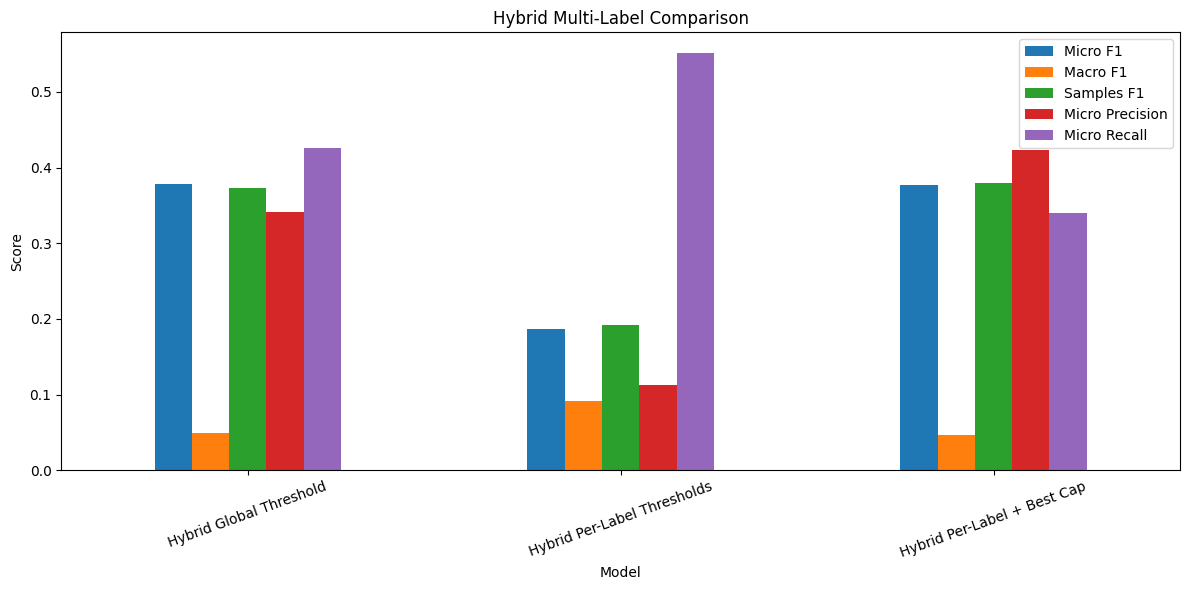

In [14]:
# ============================================================
# 14. PLOT MAIN COMPARISON
# ============================================================

plot_cols = ["Micro F1", "Macro F1", "Samples F1", "Micro Precision", "Micro Recall"]

plot_df = comparison_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Hybrid Multi-Label Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 15. SAVE OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

cap_results_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_per_label_cap_search.csv",
    index=False
)

comparison_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_per_label_comparison.csv",
    index=False
)

pd.DataFrame([final_test_results]).to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_per_label_final_test_results.csv",
    index=False
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_best_per_label_thresholds.npy",
    best_thresholds_per_label
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_per_label_test_pred.npy",
    Y_test_pred_final
)

with open("../data/processed/hybrid_multilabel_candidate150_pilot_best_per_label_cap.txt", "w") as f:
    f.write(str(best_cap_value))

print("Saved hybrid per-label threshold outputs.")

Saved hybrid per-label threshold outputs.


In [16]:
# ============================================================
# 16. INTERPRETATION NOTES
# ============================================================

print("1. This notebook improves the hybrid pilot by replacing a single global threshold with per-label thresholds.")
print("2. Per-label thresholds are learned directly from the fused validation probabilities.")
print("3. A small label-cap search is included as a cheap extra refinement step.")
print("4. The final comparison shows whether per-label decoding improves over the original hybrid configuration.")
print("5. The best version from this notebook becomes the frozen final hybrid pilot result.")

1. This notebook improves the hybrid pilot by replacing a single global threshold with per-label thresholds.
2. Per-label thresholds are learned directly from the fused validation probabilities.
3. A small label-cap search is included as a cheap extra refinement step.
4. The final comparison shows whether per-label decoding improves over the original hybrid configuration.
5. The best version from this notebook becomes the frozen final hybrid pilot result.
